## 1. Experiment Population

To evaluate the checkout experiment, we restrict the population to web sessions that were part of the A/B test.

This ensures:
- Mobile traffic noise is removed
- Only sessions exposed to the experiment are analyzed
- Variant comparison remains unbiased

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fact_sessions = pd.read_csv("../data/fact_sessions.csv")
fact_orders = pd.read_csv("../data/fact_orders.csv")
dim_users = pd.read_csv("../data/dim_users_enriched.csv")

fact_sessions["session_start_ts"] = pd.to_datetime(fact_sessions["session_start_ts"])

eligible = fact_sessions[
    (fact_sessions["device"] == "web") &
    (fact_sessions["variant"].isin(["A","B"]))
].copy()

print("Eligible Sessions:", eligible["session_id"].nunique())

Eligible Sessions: 2972


In [4]:
funnel = {
    "Eligible": len(eligible),
    "Product View": eligible["has_product_view"].sum(),
    "Add to Cart": eligible["has_add_to_cart"].sum(),
    "Begin Checkout": eligible["has_begin_checkout"].sum(),
    "Payment Attempt": eligible["has_payment_attempt"].sum(),
    "Purchase": (eligible["net_amount"] > 0).sum()
}

funnel_df = pd.DataFrame(funnel.items(), columns=["Step", "Sessions"])
funnel_df["Dropoff_from_previous"] = funnel_df["Sessions"].pct_change()

funnel_df

,Step,Sessions,Dropoff_from_previous
0,Eligible,2972,NaN
1,Product View,1849,-0.377860
2,Add to Cart,568,-0.692807
3,Begin Checkout,386,-0.320423
4,Payment Attempt,386,0.000000
5,Purchase,274,-0.290155


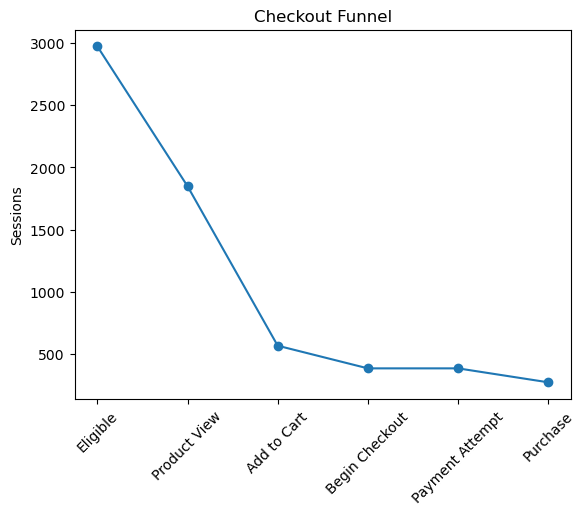

In [5]:
plt.figure()
plt.plot(funnel_df["Step"], funnel_df["Sessions"], marker="o")
plt.xticks(rotation=45)
plt.title("Checkout Funnel")
plt.ylabel("Sessions")
plt.show()

In [6]:
eligible = eligible.copy()
eligible["converted"] = eligible["net_amount"] > 0

time_analysis = eligible[eligible["has_add_to_cart"] == 1] \
                    .groupby("converted")["time_to_cart_sec"] \
                    .median()

time_analysis

converted
False    190.5
True     184.0
Name: time_to_cart_sec, dtype: float64

In [7]:
fact_sessions["week"] = fact_sessions["session_start_ts"].dt.to_period("W").astype(str)

weekly = fact_sessions.groupby("week").agg({
    "session_id": "count",
    "net_amount": "sum",
    "has_add_to_cart": "sum",
    "has_begin_checkout": "sum"
}).reset_index()

weekly["conversion_rate"] = fact_sessions.groupby("week")["net_amount"].apply(lambda x: (x>0).mean()).values
weekly["AOV"] = fact_sessions.groupby("week")["net_amount"].apply(lambda x: x[x>0].mean()).values
weekly["revenue_per_session"] = weekly["net_amount"] / weekly["session_id"]
weekly["cart_rate"] = weekly["has_add_to_cart"] / weekly["session_id"]
weekly["checkout_rate"] = weekly["has_begin_checkout"] / weekly["session_id"]

weekly

,week,session_id,net_amount,has_add_to_cart,has_begin_checkout,conversion_rate,AOV,revenue_per_session,cart_rate,checkout_rate
0,2025-10-20/2025-10-26,557,248257.2900,98,59,0.070018,6365.571538,445.704291,0.175943,0.105925
1,2025-10-27/2025-11-02,672,453925.7162,115,73,0.080357,8406.031781,675.484697,0.171131,0.108631
2,2025-11-03/2025-11-09,723,319394.9800,125,77,0.071923,6142.211154,441.763458,0.172891,0.106501
3,2025-11-10/2025-11-16,698,310246.2462,103,61,0.064470,6894.361027,444.478863,0.147564,0.087393
4,2025-11-17/2025-11-23,712,406289.7300,116,74,0.078652,7255.173750,570.631643,0.162921,0.103933
5,2025-11-24/2025-11-30,680,372547.2262,123,78,0.082353,6652.629039,547.863568,0.180882,0.114706
6,2025-12-01/2025-12-07,689,334041.1000,123,78,0.075472,6423.867308,484.820174,0.178520,0.113208
7,2025-12-08/2025-12-14,640,487269.8286,132,78,0.098437,7734.441724,761.359107,0.206250,0.121875
8,2025-12-15/2025-12-21,760,376168.8000,130,81,0.071053,6966.088889,494.958947,0.171053,0.106579
9,2025-12-22/2025-12-28,712,427404.1162,138,89,0.078652,7632.216361,600.286680,0.193820,0.125000


## A/B Test Result

- Lift: +19.4% in conversion rate (8.42% → 10.05%)
- p-value: 0.124 — NOT statistically significant at 95% confidence
- The result is directionally positive and consistent across all segments
- Recommendation: Conditional rollout to Search channel and New Users
  where lift is strongest. Run a larger test (5,000+ per arm) for full rollout.

In [8]:
device_channel = eligible.groupby(["device","channel"]).agg({
    "session_id":"count",
    "net_amount": lambda x: (x>0).mean()
}).reset_index()

device_channel

,device,channel,session_id,net_amount
0,web,email,381,0.097113
1,web,organic,1019,0.087341
2,web,paid_social,526,0.093156
3,web,referral,307,0.100977
4,web,search,739,0.092016


In [9]:
new_vs_return = eligible.groupby("is_new_user").agg({
    "session_id":"count",
    "net_amount": lambda x:(x>0).mean()
}).reset_index()

new_vs_return

,is_new_user,session_id,net_amount
0,0,2076,0.094894
1,1,896,0.085938


In [10]:
city_perf = eligible.merge(
    dim_users[["user_id","city_tier"]],
    on="user_id",
    how="left"
)

city_perf.groupby("city_tier").agg({
    "session_id":"count",
    "net_amount": lambda x:(x>0).mean()
}).reset_index()

,city_tier,session_id,net_amount
0,1,750,0.084000
1,2,1294,0.102009
2,3,928,0.085129


In [11]:
value_perf = eligible.merge(
    dim_users[["user_id","user_value_band"]],
    on="user_id",
    how="left"
)

value_perf.groupby("user_value_band").agg({
    "session_id":"count",
    "net_amount": lambda x:(x>0).mean()
}).reset_index()

,user_value_band,session_id,net_amount
0,high,1182,0.23181
1,low,832,0.00000
2,medium,958,0.00000


In [12]:
category_perf = fact_orders.groupby("category").agg({
    "order_id":"count",
    "net_amount":"mean"
}).sort_values("order_id",ascending=False)

category_perf.head()

,order_id,net_amount
category,,
Books,171,7826.049942
Beauty,167,7679.504295
Electronics,131,6121.767405
Fashion,85,6087.816308
Home,83,6448.121325


In [13]:
variant_perf = eligible.groupby("variant").agg({
    "session_id":"count",
    "net_amount": lambda x:(x>0).mean()
}).reset_index()

variant_perf

,variant,session_id,net_amount
0,A,1509,0.084162
1,B,1463,0.100478


In [14]:
A = variant_perf.loc[variant_perf["variant"]=="A","net_amount"].values[0]
B = variant_perf.loc[variant_perf["variant"]=="B","net_amount"].values[0]

uplift = B - A

B_sessions = variant_perf.loc[variant_perf["variant"]=="B","session_id"].values[0]

incremental_orders = uplift * B_sessions

AOV = eligible.loc[eligible["net_amount"]>0,"net_amount"].mean()

incremental_revenue = incremental_orders * AOV

print("Incremental Orders:", round(incremental_orders))
print("Incremental Revenue:", round(incremental_revenue))

Incremental Orders: 24
Incremental Revenue: 176162


In [35]:
eligible[eligible["variant"].isin(["A","B"])].groupby(
    ["variant","is_new_user"]
).agg({
    "net_amount": lambda x:(x>0).mean()
}).reset_index()

,variant,is_new_user,net_amount
0,A,0,0.089407
1,A,1,0.072917
2,B,0,0.100287
3,B,1,0.100962



# PART D — ADVANCED EXPERIMENT ANALYSIS


In [16]:
ab_data = eligible[eligible["variant"].isin(["A","B"])].copy()

In [17]:
ab_data.groupby("variant")["session_id"].count()

variant
A    1509
B    1463
Name: session_id, dtype: int64

In [18]:
ab_data["converted"] = ab_data["net_amount"] > 0

conversion = ab_data.groupby("variant")["converted"].mean()
conversion

variant
A    0.084162
B    0.100478
Name: converted, dtype: float64

In [19]:
rev_per_session = ab_data.groupby("variant")["net_amount"].mean()
rev_per_session

variant
A    640.193704
B    721.780578
Name: net_amount, dtype: float64

In [20]:
checkout_to_purchase = ab_data.groupby("variant").apply(
    lambda x: (x["net_amount"]>0).sum() / x["has_begin_checkout"].sum()
)

checkout_to_purchase

C:\Users\abhyu\AppData\Local\Temp\ipykernel_6520\2618068895.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  checkout_to_purchase = ab_data.groupby("variant").apply(


variant
A    0.721591
B    0.700000
dtype: float64

In [21]:
time_metrics = ab_data.groupby("variant")[[
    "time_to_checkout_sec",
    "time_to_purchase_sec"
]].median()

time_metrics

,time_to_checkout_sec,time_to_purchase_sec
variant,,
A,0.0,0.0
B,0.0,0.0


In [22]:
lift = (conversion["B"] - conversion["A"]) / conversion["A"]
print("Lift %:", lift * 100)

Lift %: 19.387409109746436


In [36]:
conversion_a = conversion["A"]
conversion_b = conversion["B"]

lift = conversion_b - conversion_a

sessions = ab_data["session_id"].nunique()

incremental_orders = sessions * lift

AOV = ab_data.loc[ab_data["net_amount"]>0,"net_amount"].mean()

incremental_revenue = incremental_orders * AOV

print("Projected Incremental Orders:", round(incremental_orders))
print("Projected Incremental Revenue:", round(incremental_revenue))

Projected Incremental Orders: 48
Projected Incremental Revenue: 357863


In [23]:
from scipy.stats import ttest_ind

A = ab_data[ab_data["variant"]=="A"]["converted"]
B = ab_data[ab_data["variant"]=="B"]["converted"]

ttest_ind(A, B)

TtestResult(statistic=-1.537289734491063, pvalue=0.12432889599307345, df=2970.0)

In [24]:
ab_data.groupby(["variant","channel"])["session_id"].count()

variant  channel    
A        email          205
         organic        527
         paid_social    257
         referral       156
         search         364
B        email          176
         organic        492
         paid_social    269
         referral       151
         search         375
Name: session_id, dtype: int64

In [25]:
# ==============================
# PART E — IMPACT ESTIMATION
# ==============================

# Conversion rates
conv_A = conversion["A"]
conv_B = conversion["B"]

# Current sessions in dataset
total_sessions = len(eligible)

# Average order value
AOV = eligible[eligible["net_amount"] > 0]["net_amount"].mean()

print("Conversion A:", conv_A)
print("Conversion B:", conv_B)
print("Total Sessions:", total_sessions)
print("Average Order Value:", AOV)

Conversion A: 0.08416169648774023
Conversion B: 0.10047846889952153
Total Sessions: 2972
Average Order Value: 7379.625127007298


In [26]:
# Incremental conversion uplift
uplift = conv_B - conv_A

# Expected incremental orders
incremental_orders = uplift * total_sessions

print("Incremental Orders:", incremental_orders)

Incremental Orders: 48.49344760781401


In [27]:
incremental_revenue = incremental_orders * AOV

print("Projected Incremental Revenue:", incremental_revenue)

Projected Incremental Revenue: 357863.4644618362


In [28]:
days = 30
daily_sessions = total_sessions / days

monthly_incremental_orders = uplift * daily_sessions * 30
monthly_incremental_revenue = monthly_incremental_orders * AOV

print("Projected Orders (30 days):", monthly_incremental_orders)
print("Projected Revenue (30 days):", monthly_incremental_revenue)

Projected Orders (30 days): 48.49344760781401
Projected Revenue (30 days): 357863.4644618362


In [29]:
best_case = incremental_revenue * 1.2
base_case = incremental_revenue
worst_case = incremental_revenue * 0.8

print("Best Case Revenue:", best_case)
print("Base Case Revenue:", base_case)
print("Worst Case Revenue:", worst_case)

Best Case Revenue: 429436.15735420346
Base Case Revenue: 357863.4644618362
Worst Case Revenue: 286290.77156946895


In [30]:
margin = 0.30

incremental_profit = incremental_revenue * margin

print("Projected Profit Impact:", incremental_profit)

Projected Profit Impact: 107359.03933855087
